# Phase 0 (Obj A): Lucas-Style Motivation and Replication

This notebook builds the motivation layer: a Lucas-style cross-country comparison between money growth, inflation, and GDP growth.

## What this notebook does (and how it maps to Lucas 1980)

Lucas’s paper gives **two quantity-theoretic “laws” in long run / low frequency**: (i) a change in money growth maps into **inflation** about one-for-one; (ii) the same change maps into **nominal interest rates** about one-for-one (Fisher / nominal rate tracks inflation). His **first** illustration is cross-country money vs inflation (similar spirit to our country-mean inflation plot). His **second** illustration uses **U.S. quarterly** data: **M1 growth, CPI inflation, and the 90-day T-bill rate** with moving-average filters — not a GDP-growth regression.

**This repo’s panel (`macro_growth_merged.csv`) has M2 growth, inflation, and GDP growth — it does *not* contain a harmonized short nominal interest rate.** So we **do not** replicate the T-bill half of Lucas here. The **second figure** in this notebook (money vs **GDP growth**) is a **descriptive add-on** (“real side / super-neutrality lite”), not Lucas’s interest-rate illustration. To mirror Lucas (ii) properly you would need to merge a comparable **policy or money-market rate** (e.g., World Bank lending rate, IMF IFS, or FRED for a U.S.-only appendix).

Steps in code:

1. Load the merged country-year panel.
2. Pooled OLS: money growth → inflation; money growth → GDP growth.
3. Long-run country-average regressions (`n_obs >= 30` filter).
4. Export phase-0 tables/plots under `exports/phase0`.


In [1]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

sns.set_theme(style="whitegrid")


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "02_data/analysis_ready/macro_growth_merged.csv").exists():
            return candidate
    raise FileNotFoundError("Could not find project root with analysis-ready data.")


ROOT = find_project_root(Path.cwd().resolve())
PANEL_PATH = ROOT / "02_data/analysis_ready/macro_growth_merged.csv"
OUT_DIR = ROOT / "03_analysis_notebooks/exports/phase0"
OUT_DIR.mkdir(parents=True, exist_ok=True)
ROOT

PosixPath('/Users/stevenchung/Desktop/P12B_File/Monetary_Panel')

In [2]:
df = pd.read_csv(PANEL_PATH)
df = df.rename(columns={"Country Name": "country"})

summary = pd.DataFrame({
    "metric": ["rows", "countries", "year_min", "year_max"],
    "value": [len(df), df["country"].nunique(), int(df["year"].min()), int(df["year"].max())],
})
summary

,metric,value
0,rows,4750
1,countries,160
2,year_min,1991
3,year_max,2024


In [3]:
pooled_infl = smf.ols("inflation ~ m2_growth", data=df.dropna(subset=["inflation", "m2_growth"])).fit(cov_type="HC1")
pooled_gdp = smf.ols("gdp_growth ~ m2_growth", data=df.dropna(subset=["gdp_growth", "m2_growth"])).fit(cov_type="HC1")

pooled_results = pd.DataFrame([
    {
        "model": "pooled_inflation",
        "coef_m2_growth": float(pooled_infl.params["m2_growth"]),
        "p_value": float(pooled_infl.pvalues["m2_growth"]),
        "adj_r2": float(pooled_infl.rsquared_adj),
        "nobs": int(pooled_infl.nobs),
    },
    {
        "model": "pooled_gdp_growth",
        "coef_m2_growth": float(pooled_gdp.params["m2_growth"]),
        "p_value": float(pooled_gdp.pvalues["m2_growth"]),
        "adj_r2": float(pooled_gdp.rsquared_adj),
        "nobs": int(pooled_gdp.nobs),
    },
])
pooled_results

,model,coef_m2_growth,p_value,adj_r2,nobs
0,pooled_inflation,0.732084,2.061023e-07,0.566038,4750
1,pooled_gdp_growth,0.001634,8.133630e-01,-0.000164,4750


In [4]:
country_avg = (
    df.groupby("country", as_index=False)
    .agg(
        m2_growth=("m2_growth", "mean"),
        inflation=("inflation", "mean"),
        gdp_growth=("gdp_growth", "mean"),
        n_obs=("year", "count"),
    )
)
country_avg_30 = country_avg[country_avg["n_obs"] >= 30].copy()

longrun_infl = smf.ols("inflation ~ m2_growth", data=country_avg_30.dropna(subset=["inflation", "m2_growth"])).fit()
longrun_gdp = smf.ols("gdp_growth ~ m2_growth", data=country_avg_30.dropna(subset=["gdp_growth", "m2_growth"])).fit()

longrun_results = pd.DataFrame([
    {
        "model": "longrun_inflation_country_avg",
        "coef_m2_growth": float(longrun_infl.params["m2_growth"]),
        "p_value": float(longrun_infl.pvalues["m2_growth"]),
        "adj_r2": float(longrun_infl.rsquared_adj),
        "nobs": int(longrun_infl.nobs),
    },
    {
        "model": "longrun_gdp_country_avg",
        "coef_m2_growth": float(longrun_gdp.params["m2_growth"]),
        "p_value": float(longrun_gdp.pvalues["m2_growth"]),
        "adj_r2": float(longrun_gdp.rsquared_adj),
        "nobs": int(longrun_gdp.nobs),
    },
])
longrun_results

,model,coef_m2_growth,p_value,adj_r2,nobs
0,longrun_inflation_country_avg,0.951599,4.411391e-50,0.876037,108
1,longrun_gdp_country_avg,0.016277,4.840252e-01,-0.004759,108


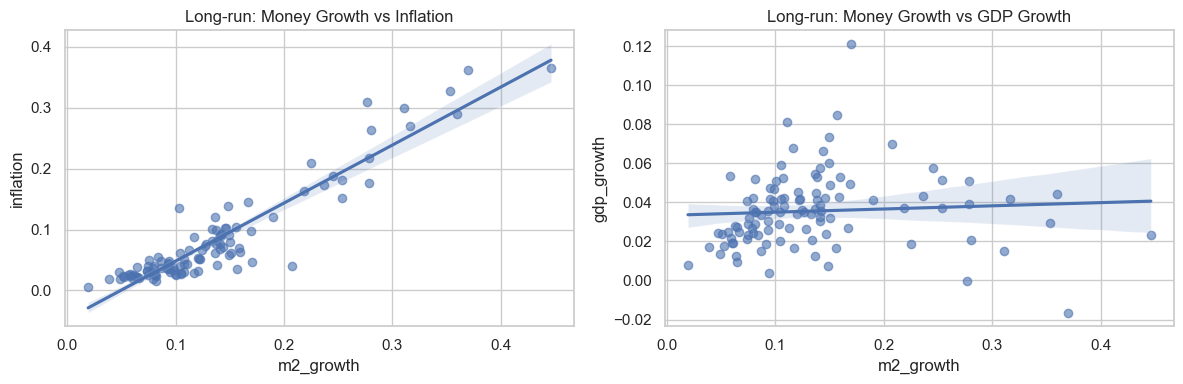

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.regplot(data=country_avg_30, x="m2_growth", y="inflation", scatter_kws={"alpha": 0.6}, ax=axes[0])
axes[0].set_title("Long-run: Money Growth vs Inflation")

sns.regplot(data=country_avg_30, x="m2_growth", y="gdp_growth", scatter_kws={"alpha": 0.6}, ax=axes[1])
axes[1].set_title("Long-run: Money Growth vs GDP Growth")

fig.tight_layout()
fig.savefig(OUT_DIR / "phase0_longrun_scatter.png", dpi=170)
plt.show()

In [6]:
pooled_results.to_csv(OUT_DIR / "phase0_pooled_results.csv", index=False)
longrun_results.to_csv(OUT_DIR / "phase0_longrun_results.csv", index=False)
country_avg_30.to_csv(OUT_DIR / "phase0_country_averages_n30.csv", index=False)
summary.to_csv(OUT_DIR / "phase0_sample_summary.csv", index=False)

print("Saved Phase 0 outputs to:", OUT_DIR)

Saved Phase 0 outputs to: /Users/stevenchung/Desktop/P12B_File/Monetary_Panel/03_analysis_notebooks/exports/phase0


## Interpretation for Obj A

- If inflation loads strongly on money growth in pooled and long-run country-average views, the Lucas **(i)** money–inflation block is supported in spirit.
- Lucas **(ii)** (money–**nominal interest rate**) is **not estimated here** — no interest-rate series in the panel; do not cite the GDP scatter as “Lucas’s second illustration.”
- GDP vs money remains a **weak descriptive** counterpart for the real margin only.
- Move to notebook **02** for FE/IV + Phillips baseline under Obj **B** (YoY).


## Obj A — Clean sample (no hyperinflation: max annual inflation < 40%)

The full-sample slope is dominated by post-Soviet and Latin American hyperinflation episodes (early 1990s).
The clean sample (123 countries) removes these and focuses on the modern, non-hyperinflationary world — the relevant population for the QE/COVID question.

Clean sample (n>=30, n=83 countries)
M2->inflation: slope=0.5235 p=6.80e-15 R2=0.529
M2->GDP:       slope=0.2833 p=0.0000 R2=0.291


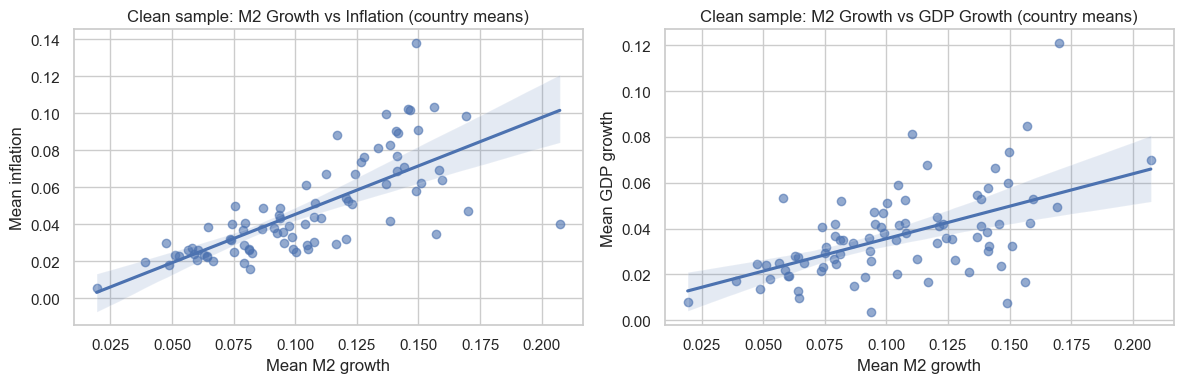

In [7]:
# ── Obj A: clean sample scatter ─────────────────────────────────────────────
clean = df[df['sample_low_inflation'] == 1]

ca_clean = (
    clean.groupby('country', as_index=False)
    .agg(m2_avg=('m2_growth','mean'), inf_avg=('inflation','mean'),
         gdp_avg=('gdp_growth','mean'), n=('year','count'))
)
ca_clean30 = ca_clean[ca_clean['n'] >= 30]

fit_inf_c = smf.ols('inf_avg ~ m2_avg', data=ca_clean30.dropna()).fit()
fit_gdp_c = smf.ols('gdp_avg ~ m2_avg', data=ca_clean30.dropna()).fit()

print(f'Clean sample (n>={30}, n={len(ca_clean30)} countries)')
print(f'M2->inflation: slope={fit_inf_c.params["m2_avg"]:.4f}',
      f'p={fit_inf_c.pvalues["m2_avg"]:.2e}',
      f'R2={fit_inf_c.rsquared:.3f}')
print(f'M2->GDP:       slope={fit_gdp_c.params["m2_avg"]:.4f}',
      f'p={fit_gdp_c.pvalues["m2_avg"]:.4f}',
      f'R2={fit_gdp_c.rsquared:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.regplot(data=ca_clean30, x='m2_avg', y='inf_avg',
            scatter_kws={'alpha':0.6}, ax=axes[0])
axes[0].set_title('Clean sample: M2 Growth vs Inflation (country means)')
axes[0].set_xlabel('Mean M2 growth'); axes[0].set_ylabel('Mean inflation')

sns.regplot(data=ca_clean30, x='m2_avg', y='gdp_avg',
            scatter_kws={'alpha':0.6}, ax=axes[1])
axes[1].set_title('Clean sample: M2 Growth vs GDP Growth (country means)')
axes[1].set_xlabel('Mean M2 growth'); axes[1].set_ylabel('Mean GDP growth')
fig.tight_layout()
plt.show()

## Obj A — Lucas (ii) spirit: cross-country M2 growth vs nominal interest rate

Lucas's second illustration uses money growth vs nominal interest rates. The cross-country panel has no harmonised policy rate,
but World Bank lending rates (`FR.INR.LEND`) cover 107 clean-sample countries.
This is the cross-country extension of the US appendix in `05_lucas_us_appendix.ipynb`.

n=107 countries
M2->lending rate: slope=0.4913 p=0.0000 R2=0.158


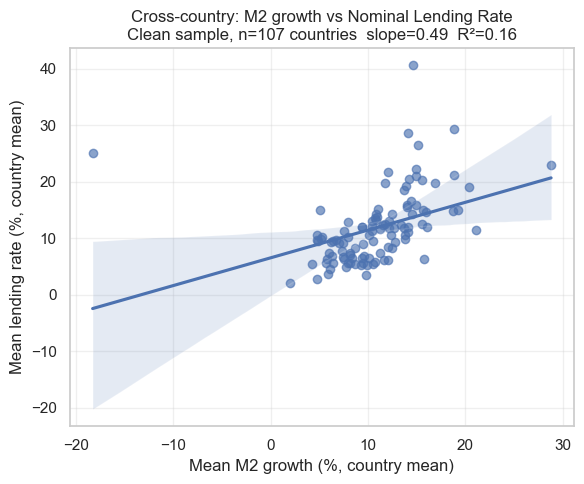

Note: lending rate includes bank spread above policy rate — slope dampened vs T-bill.


In [8]:
from pathlib import Path as _Path
import pandas as _pd

rates = _pd.read_csv(ROOT / '02_data/supporting/intl_lending_rates.csv')
rates = rates.rename(columns={'Country Name': 'country'})

rate_avg = rates[rates['country'].isin(clean['country'])].groupby('country', as_index=False).agg(
    rate_avg=('lending_rate_pct','mean')
)

# put M2 in percent for same units as rate
ca_rate = ca_clean.merge(rate_avg, on='country').dropna()
ca_rate['m2_pct'] = ca_rate['m2_avg'] * 100

fit_rate = smf.ols('rate_avg ~ m2_pct', data=ca_rate).fit()
print(f'n={len(ca_rate)} countries')
print(f'M2->lending rate: slope={fit_rate.params["m2_pct"]:.4f}',
      f'p={fit_rate.pvalues["m2_pct"]:.4f}',
      f'R2={fit_rate.rsquared:.3f}')

fig, ax = plt.subplots(figsize=(6, 5))
sns.regplot(data=ca_rate, x='m2_pct', y='rate_avg',
            scatter_kws={'alpha':0.65}, ax=ax)
ax.set_xlabel('Mean M2 growth (%, country mean)')
ax.set_ylabel('Mean lending rate (%, country mean)')
ax.set_title(f'Cross-country: M2 growth vs Nominal Lending Rate\n'
             f'Clean sample, n={len(ca_rate)} countries  '
             f'slope={fit_rate.params["m2_pct"]:.2f}  R²={fit_rate.rsquared:.2f}')
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()
print('Note: lending rate includes bank spread above policy rate — slope dampened vs T-bill.')